<a href="https://colab.research.google.com/github/ashisrivastavaa/Learning-ML/blob/main/linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

In [ ]:
#Data Generate X,Y
def GenerateDataset(m):
  X =np.random.randn(m)*10 #in randn most no. b/w -1 to 1 & by *10 tha most of the data is b/w -10 to 10
  noise=np.random.randn(m) #adding noise to data
  Y=3*X+1+5*noise #function for linear regression
  return X,Y
X,Y=GenerateDataset(100)
print(X.shape,Y.shape)



(100,) (100,)


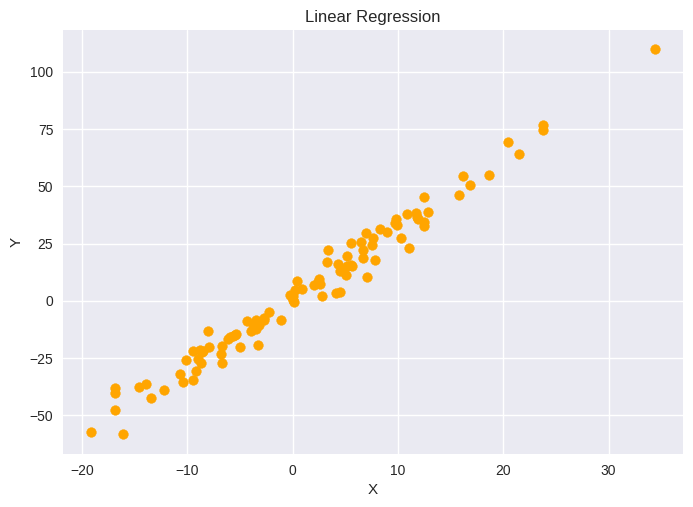

In [ ]:
def plotData(X,Y,colors='orange',title='Linear Regression'):
  plt.title(title)
  plt.xlabel('X')
  plt.ylabel('Y')
  plt.scatter(X,Y,c=colors)
  plt.show()
plotData(X,Y)

the data centered from -10 to 10


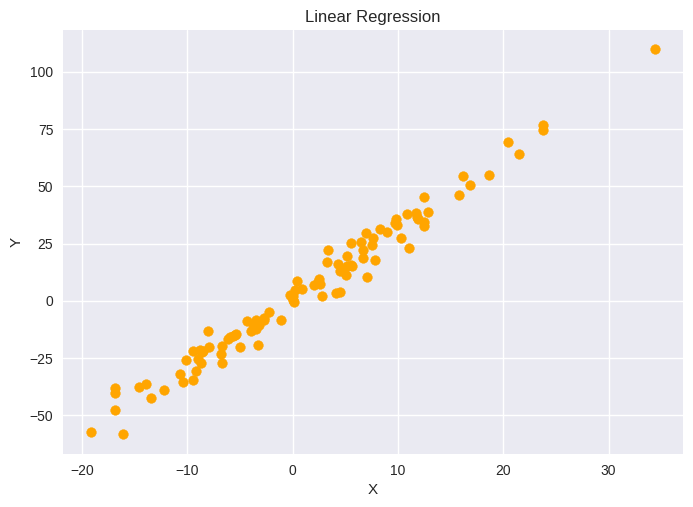

the data centered from -1 to 1


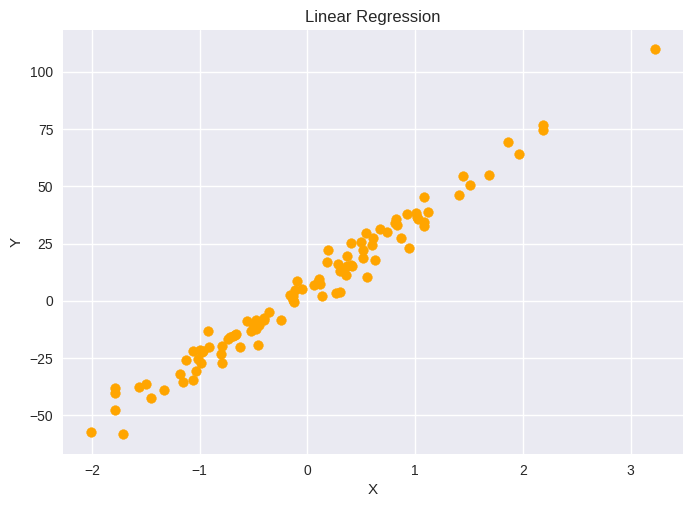

In [ ]:
#Data normalization
def NormalizeData(X):
    return (X - X.mean()) / X.std() #standardization(it affect the center of the data and spread of the data)

print("the data centered from -10 to 10")
plotData(X, Y)

X = NormalizeData(X)   # normalized data

print("the data centered from -1 to 1")
plotData(x, Y)

In [ ]:
#Train Test Split
def TrainTestSplit(X,Y,split=0.8): #take 80-20
  m=X.shape[0] #here we have 100 sample as we define earlier
  data=np.zeros((m,2)) #take new  matrix name data with m rows and 2 columns
  data[:,0]=X #X value copied in 0th column
  data[:,1]=Y #Y value copied in 1st column
  np.random.shuffle(data) #shuffle the data (it shuffle row by row)
  split=int(m*split) #split=80 80 rows go into training and 20 rows go into testing)
  TrainsX=data[:split,0] #training X side data (take all the rows upto split of column 0)
  TrainsY=data[:split,1] #training Yside data (take all the rows upto split of column 1)
  TestsX=data[split:,0] #testing X side data (take all the rows from split till last of column 0)
  TestsY=data[split:,1] #testing Y side data (take all the rows from split till last of column 1)
  return TrainsX,TrainsY,TestsX,TestsY


In [ ]:
TrainsX,TrainsY,TestsX,TestsY=TrainTestSplit(X,Y)

In [ ]:
print("80 samples in x train & 80 samples in y train")
print(TrainsX.shape,TrainsY.shape)
print("20 samples in x test & 20 samples in y test")
print(TestsX.shape,TestsY.shape)

80 samples in x train & 80 samples in y train
(80,) (80,)
20 samples in x test & 20 samples in y test
(20,) (20,)


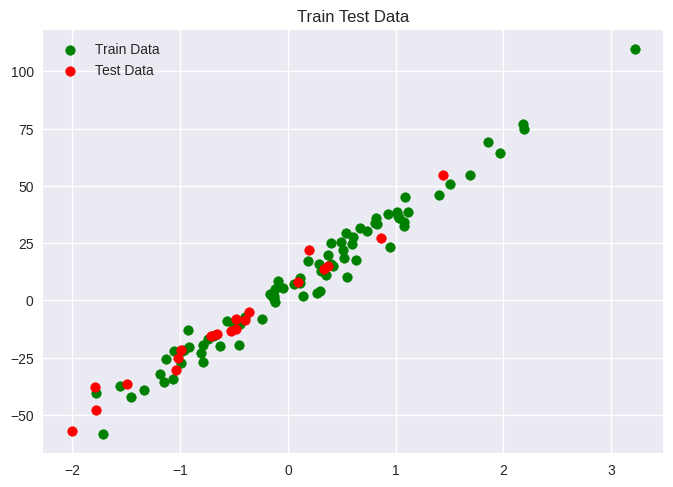

In [ ]:
plt.scatter(TrainsX,TrainsY,color='green', label="Train Data")
plt.scatter(TestsX,TestsY,color='red', label="Test Data")
plt.legend() #for showing label on graph
plt.title("Train Test Data")
plt.show()

In [ ]:
#Hypothesis
def hypothesis(x,theta):#x is scaler , theta is vector(theta0 and theta1)
  return theta[0]+theta[1]*x

def error(x,y,theta):
  m=x.shape[0]
  e=0 # total error is 0
  for i in range(m):
    y_=hypothesis(x[i],theta)
    e += (y[i] - y_)**2
  return e/(2*m)  #mean squared error

def gradient(x,y,theta):
  m=x.shape[0]
  grad=np.zeros((2,))

  for i in range(m):
    exp=hypothesis(x[i],theta)-y[i]
    grad[0]=grad[0]+(exp)  #diff wrt theta0
    grad[1]=grad[1]+(exp)*x[i] #diff wrt theta1
  return grad/m

def train(x,y,lr=0.1,maxTitr=100):
  theta=np.zeros((2,))


  error_list=[]
  for i in range(maxTitr):
    grad=gradient(x,y,theta)
    error_list.append(error(x,y,theta)) #visualize error is increasing or decreasing
    theta[0]=theta[0]-lr*grad[0]
    theta[1]=theta[1]-lr*grad[1]
  plt.xlabel("Iteration Number")
  plt.ylabel("Error")
  plt.title("Error vs Iteration")
  plt.plot(error_list)
  plt.show()
  return theta


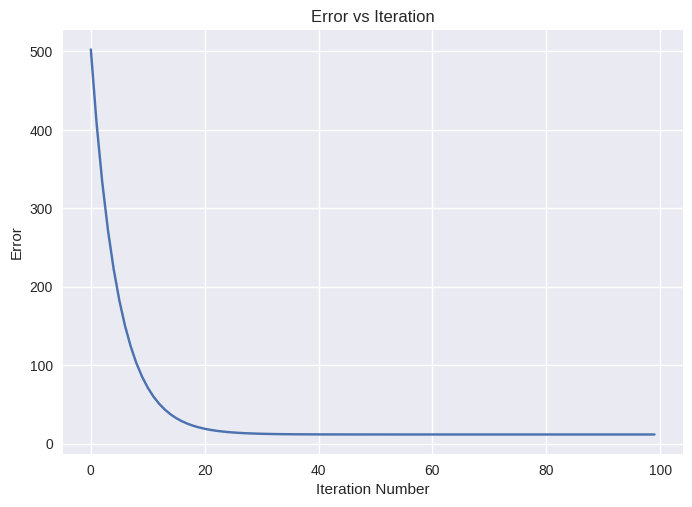

In [ ]:
theta=train(x,Y)

In [ ]:
theta

array([ 5.33737833, 30.86773861])

In [ ]:
def predict(x,theta):
  return hypothesis(x,theta)

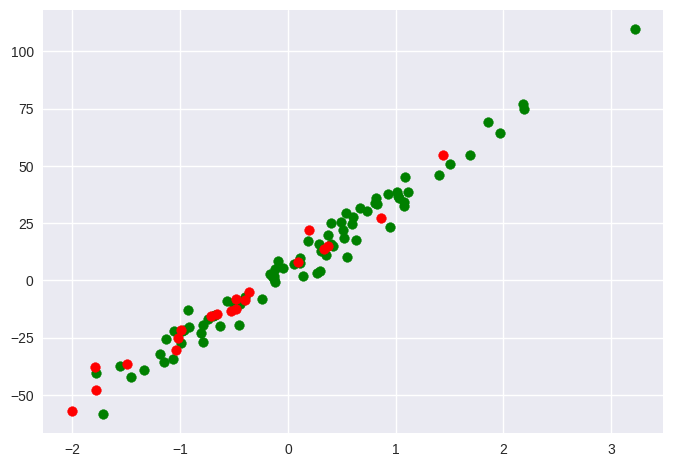

In [ ]:
plt.scatter(TrainsX,TrainsY,color='green', label="Train Data")
plt.scatter(TestsX,TestsY,color='red', label="Test Data")
plt.show()

In [ ]:
ypredict=predict(TestsX,theta)

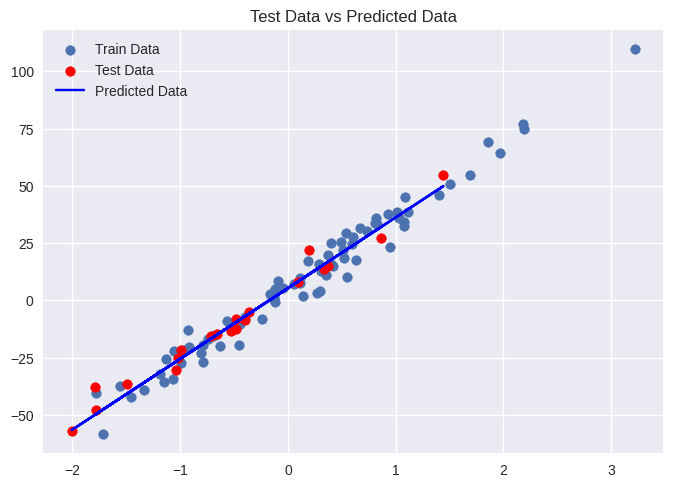

In [ ]:
plt.scatter(TrainsX,TrainsY,label="Train Data")
plt.scatter(TestsX,TestsY,color='red', label="Test Data")
plt.plot(TestsX,ypredict,color='blue', label="Predicted Data")
plt.legend() #for showing label on graph
plt.title("Test Data vs Predicted Data")
plt.show()

In [ ]:
#Model Evaluation
#R2 Score-> mathematics way to see how good or bad model is
def r2Score(y,yp):
  ymean=y.mean()
  num=np.sum((y-yp)**2)
  denom=np.sum((y-ymean)**2)
  return 1-num/denom

r2Score(TestsY,ypredict)


np.float64(0.9725790187912781)